# 10 — Model interpretation

This notebook explains which clinical variables the final Notebook 09 pipelines rely on. For each model it reports three things:

- whether the final full-cohort pipeline retained the variable;
- how often the variable was selected across Notebook 07's 20 outer-training refits (stability);
- **out-of-fold grouped permutation importance**: the drop in macro F1 and rare-fall recall when that variable is shuffled among held-out patients.

Permutation importance is measured on held-out folds because the unlimited-depth Stage 2 forest would look artificially dependent on many variables if scored on its own training patients. Copies of the saved pipelines are refitted, with the frozen settings, on four of Notebook 09's five seed-42 folds and scored on the fifth. `shap` is not installed in this environment, so SHAP values are not produced.

**Boundary:** importance describes what these fitted models use. It is not causal, and a variable with low importance may still be clinically relevant when correlated variables carry the same information. Nothing here changes the models or produces a performance estimate.

## 1. Setup

Load the tools, locate the Notebook 07 and 09 artifacts, and create the output folder.

In [1]:
import os

# Avoid noisy macOS physical-core detection in joblib.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(max(1, (os.cpu_count() or 2) - 1)))

from pathlib import Path
import hashlib
import io
import json
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score

working_directory = Path.cwd().resolve()
project_root = next(
    (
        folder
        for folder in [working_directory, *working_directory.parents]
        if (folder / "AGENTS.md").is_file() and (folder / "docs/research_protocol.md").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Launch this notebook from within the project directory.")

final_run_directory = project_root / "results/final_pipeline/06_final_fit_and_performance_summary"
full_fit_directory = final_run_directory / "09_full_cohort_fit"
output_directory = project_root / "results/final_pipeline/08_interpretation_and_reporting/10_model_interpretation"
output_directory.mkdir(parents=True, exist_ok=True)

input_paths = {
    "predictors": final_run_directory / "02_patient_level_aggregation/primary_1040_26_predictors.csv",
    "outcomes": final_run_directory / "02_patient_level_aggregation/primary_1040_outcome_metadata.csv",
    "folds": full_fit_directory / "full_cohort_fold_assignments.csv",
    "final_pipelines": full_fit_directory / "full_cohort_selected_pipelines.csv",
    "full_fit_validation": full_fit_directory / "full_cohort_validation.csv",
    "model_manifest": full_fit_directory / "models/model_manifest.json",
    "outer_selected_pipelines": final_run_directory / "07_tuning_and_outer_evaluation/selected_pipelines.csv",
}
missing_inputs = [name for name, path in input_paths.items() if not path.is_file()]
assert not missing_inputs, f"Missing required inputs: {missing_inputs}"
print("Output directory:", output_directory.relative_to(project_root))

Output directory: results/final_pipeline/08_interpretation_and_reporting/10_model_interpretation


## 2. Load the data and verify the saved models

The model files must match the SHA-256 hashes recorded by Notebook 09, and Notebook 09's validation must have passed.

In [2]:
def file_digest(file_path):
    return hashlib.sha256(Path(file_path).read_bytes()).hexdigest()


predictors = pd.read_csv(input_paths["predictors"], dtype={"PATNO": "string"}, low_memory=False).set_index("PATNO")
outcomes = pd.read_csv(
    input_paths["outcomes"], dtype={"PATNO": "string"}, usecols=["PATNO", "falls_class"],
).set_index("PATNO")["falls_class"].astype(int)
folds = pd.read_csv(input_paths["folds"], dtype={"PATNO": "string"})
final_pipelines = pd.read_csv(input_paths["final_pipelines"])
outer_selected = pd.read_csv(input_paths["outer_selected_pipelines"])
model_manifest = json.loads(input_paths["model_manifest"].read_text())

targets = ["direct", "stage_1", "stage_2"]
models = {}
for target_name in targets:
    entry = model_manifest["models"][target_name]
    model_path = full_fit_directory / "models" / entry["file"]
    assert file_digest(model_path) == entry["sha256"], f"{entry['file']} changed after Notebook 09"
    with open(model_path, "rb") as handle:
        models[target_name] = pickle.load(handle)

assert pd.read_csv(input_paths["full_fit_validation"])["passed"].astype(str).str.lower().eq("true").all()
assert predictors.columns.tolist() == model_manifest["input_columns"]
assert set(folds["PATNO"]) == set(predictors.index)
display(final_pipelines[["target", "model_family", "selector", "selected_group_count", "training_patients"]])

,target,model_family,selector,selected_group_count,training_patients
0,direct,catboost,corrected_fdr,20,1040
1,stage_1,extra_trees,corrected_fdr,20,1040
2,stage_2,random_forest,extra_trees,13,328


## 3. Define the clinical variable groups

Each source variable is shuffled on its own; the Neuro-QoL questionnaire enters only as its 8-item Gaussian mobility score. The derived missing-form indicators are recomputed inside the pipeline, so they move with their source values. Group names match the representation groups used during feature selection.

In [3]:
NEUROQOL_BLOCK = ["NQ_GAUSSIAN_REVISION"]
GROUP_NAME = {"FRZGT12M": "GROUP_FREEZING_FORM", "NP4TOT": "GROUP_PART_IV_FORM"}
LABELS = {
    "Years_since_PD_diagnosis": "Years since PD diagnosis",
    "Age": "Age",
    "DXPOSINS": "Postural instability at diagnosis",
    "DXRIGID": "Rigidity at diagnosis",
    "DOPTHERST": "Dopaminergic therapy started",
    "MCATOT": "MoCA total (cognition)",
    "GROUP_FREEZING_FORM": "Freezing of gait, preceding 12 months",
    "SCAU14": "Lightheadedness on standing up (SCOPA-AUT)",
    "SCAU16": "Fainting in preceding six months (SCOPA-AUT)",
    "GDS_TOTAL": "Geriatric Depression Scale total",
    "GROUP_NEUROQOL_FORM": "Neuro-QoL Gaussian mobility score (8 items)",
    "NP1RTOT": "MDS-UPDRS Part I rater total",
    "BMI": "Body mass index",
    "NP1SLPD": "Daytime sleepiness",
    "NP1URIN": "Urinary problems",
    "NP3GAIT_COMBINED_MAX": "Gait (MDS-UPDRS Part III)",
    "NP3PSTBL_COMBINED_MAX": "Postural stability (MDS-UPDRS Part III)",
    "NHY_COMBINED_MAX": "Hoehn and Yahr stage",
    "FEATPOSHYP": "Symptomatic orthostatic hypotension documented",
    "NP3TOT_COMBINED_MAX": "MDS-UPDRS Part III motor total",
    "GROUP_PART_IV_FORM": "MDS-UPDRS Part IV total (motor complications)",
    "ANYFAMPD": "Family history of PD",
    "DXTREMOR": "Tremor at diagnosis",
    "DXBRADY": "Bradykinesia at diagnosis",
    "DOMSIDE": "Dominant side at diagnosis",
    "NP1CNST": "Constipation",
}

permutation_groups = {"GROUP_NEUROQOL_FORM": NEUROQOL_BLOCK}
for column in predictors.columns:
    if column not in NEUROQOL_BLOCK:
        permutation_groups[GROUP_NAME.get(column, column)] = [column]

covered = [column for columns in permutation_groups.values() for column in columns]
assert sorted(covered) == sorted(predictors.columns) and len(covered) == len(set(covered))
assert set(permutation_groups) == set(LABELS)
print("Permutation groups:", len(permutation_groups))

Permutation groups: 26


## 4. Summarize final retention and outer-refit stability

Record whether each final pipeline retained each group, and in how many of Notebook 07's 20 outer-training refits that target's pipeline retained it. Engineered pipelines keep every source group, with PCA blocks represented by components.

In [4]:
def groups_of(text):
    return set(str(text).split(" | "))


retention_rows = []
for target_name in targets:
    final_groups = groups_of(final_pipelines.set_index("target").loc[target_name, "selected_groups"])
    seed_groups = outer_selected.loc[outer_selected["target"].eq(target_name), "selected_groups"].map(groups_of)
    for group in permutation_groups:
        retention_rows.append({
            "target": target_name,
            "group": group,
            "label": LABELS[group],
            "final_model_uses": group in final_groups,
            "outer_refits_selected": int(seed_groups.map(lambda names: group in names).sum()),
            "outer_refits": len(seed_groups),
        })
retention = pd.DataFrame(retention_rows)
display(retention.pivot(index="label", columns="target", values="outer_refits_selected"))

target,direct,stage_1,stage_2
label,,,
Age,13,18,4
Body mass index,6,14,4
Bradykinesia at diagnosis,7,13,6
Constipation,18,20,6
Daytime sleepiness,13,10,11
Dominant side at diagnosis,7,7,10
Dopaminergic therapy started,15,17,7
Fainting in preceding six months (SCOPA-AUT),12,10,4
Family history of PD,16,12,13


## 5. Define the out-of-fold refit and scoring

Clone each saved pipeline, which keeps its frozen settings and seed, and refit it on four folds; Stage 2 uses only the fallers. Any warning during refitting stops the notebook. Scores cover the direct system, the hard-routed two-stage system, and each stage on its own target.

In [5]:
def fit_checked(estimator, X, y, context):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        estimator.fit(X, y)
    if caught:
        raise RuntimeError(f"{context} emitted a warning: {caught[0].message}")
    return estimator


def predict_classes(pipeline, frame):
    return np.asarray(pipeline.predict(frame)).astype(int).reshape(-1)


def score_all(fitted, frame, truth):
    direct = predict_classes(fitted["direct"], frame)
    stage_1 = predict_classes(fitted["stage_1"], frame)
    stage_2 = predict_classes(fitted["stage_2"], frame)
    two_stage = np.where(stage_1 == 0, 0, stage_2 + 1)
    fallers = truth > 0

    def three_class(predicted):
        recalls = recall_score(truth, predicted, labels=[0, 1, 2], average=None, zero_division=0)
        return f1_score(truth, predicted, labels=[0, 1, 2], average="macro", zero_division=0), recalls[1]

    direct_f1, direct_rare = three_class(direct)
    two_stage_f1, two_stage_rare = three_class(two_stage)
    stage_2_truth = (truth[fallers] == 2).astype(int)
    return {
        ("direct_system", "macro_f1"): direct_f1,
        ("direct_system", "rare_fall_recall"): direct_rare,
        ("two_stage_system", "macro_f1"): two_stage_f1,
        ("two_stage_system", "rare_fall_recall"): two_stage_rare,
        ("stage_1", "macro_f1"): f1_score((truth > 0).astype(int), stage_1, labels=[0, 1], average="macro", zero_division=0),
        ("stage_2", "macro_f1"): f1_score(stage_2_truth, stage_2[fallers], labels=[0, 1], average="macro", zero_division=0),
        ("stage_2", "rare_fall_recall"): recall_score(stage_2_truth, stage_2[fallers], labels=[0, 1], average=None, zero_division=0)[0],
    }


def refit_fold(inner_fold):
    training_ids = sorted(folds.loc[folds["inner_validation_fold"].ne(inner_fold), "PATNO"])
    y_train = outcomes.loc[training_ids]
    fallers = y_train[y_train.gt(0)]
    targets_for_fit = {
        "direct": (training_ids, y_train),
        "stage_1": (training_ids, y_train.gt(0).astype(int)),
        "stage_2": (fallers.index.tolist(), fallers.eq(2).astype(int)),
    }
    return {
        target_name: fit_checked(
            clone(models[target_name]),
            predictors.loc[ids],
            labels,
            f"fold {inner_fold} {target_name} refit",
        )
        for target_name, (ids, labels) in targets_for_fit.items()
    }

## 6. Run the grouped permutation importance

For each held-out fold, score the unshuffled patients, then shuffle each group ten times among those patients and record the average drop. A positive drop means the models rely on that variable. This takes a few minutes.

In [6]:
N_REPEATS = 10
RANDOM_SEED = 42

importance_rows = []
baseline_rows = []
for inner_fold in sorted(folds["inner_validation_fold"].unique()):
    fitted = refit_fold(inner_fold)
    held_out_ids = sorted(folds.loc[folds["inner_validation_fold"].eq(inner_fold), "PATNO"])
    held_out = predictors.loc[held_out_ids]
    truth = outcomes.loc[held_out_ids].to_numpy()
    baseline = score_all(fitted, held_out, truth)
    baseline_rows.extend(
        {"inner_validation_fold": inner_fold, "model": model, "metric": metric, "value": value}
        for (model, metric), value in baseline.items()
    )

    rng = np.random.default_rng(RANDOM_SEED + inner_fold)
    for group, columns in permutation_groups.items():
        drops = {key: [] for key in baseline}
        for _ in range(N_REPEATS):
            shuffled = held_out.copy()
            order = rng.permutation(len(held_out))
            shuffled[columns] = held_out[columns].iloc[order].set_axis(held_out.index)
            for key, value in score_all(fitted, shuffled, truth).items():
                drops[key].append(baseline[key] - value)
        importance_rows.extend(
            {
                "inner_validation_fold": inner_fold,
                "group": group,
                "model": model,
                "metric": metric,
                "mean_drop": float(np.mean(values)),
            }
            for (model, metric), values in drops.items()
        )
    print(f"Fold {inner_fold} complete", flush=True)

fold_importance = pd.DataFrame(importance_rows)
fold_baseline = pd.DataFrame(baseline_rows)
print("Fold-level importance rows:", len(fold_importance))

Fold 0 complete
Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold-level importance rows: 910


## 7. Summarize importance across folds

Average the five fold-level drops and report their fold standard deviation. The baseline out-of-fold scores are shown only as context for the size of the drops; the same folds chose this pipeline, so they are optimistic and are not performance estimates.

In [7]:
importance_summary = fold_importance.groupby(["model", "metric", "group"], as_index=False).agg(
    mean_drop=("mean_drop", "mean"),
    sd_drop=("mean_drop", "std"),
    folds_positive=("mean_drop", lambda values: int((values > 0).sum())),
)
importance_summary["label"] = importance_summary["group"].map(LABELS)
baseline_summary = fold_baseline.groupby(["model", "metric"], as_index=False)["value"].mean().rename(
    columns={"value": "reference_out_of_fold_score"}
)

system_table = importance_summary.loc[
    importance_summary["model"].isin(["direct_system", "two_stage_system"])
].pivot_table(index="label", columns=["model", "metric"], values="mean_drop")
system_table = system_table.sort_values(("direct_system", "macro_f1"), ascending=False)
display(baseline_summary.round(3))
display(system_table.round(4).head(12))

,model,metric,reference_out_of_fold_score
0,direct_system,macro_f1,0.528
1,direct_system,rare_fall_recall,0.440
2,stage_1,macro_f1,0.680
3,stage_2,macro_f1,0.677
4,stage_2,rare_fall_recall,0.886
5,two_stage_system,macro_f1,0.541
6,two_stage_system,rare_fall_recall,0.441


model                                         direct_system                   \
metric                                             macro_f1 rare_fall_recall   
label                                                                          
Constipation                                         0.0209           0.0480   
Freezing of gait, preceding 12 months                0.0206          -0.0485   
Neuro-QoL Gaussian mobility score (8 items)          0.0189          -0.0146   
Age                                                  0.0134           0.0463   
MDS-UPDRS Part III motor total                       0.0087           0.0170   
Urinary problems                                     0.0063           0.0056   
Daytime sleepiness                                   0.0062           0.0071   
Family history of PD                                 0.0044          -0.0100   
MDS-UPDRS Part IV total (motor complications)        0.0027          -0.0541   
MoCA total (cognition)                               0.0012           0.0007   
Bradykinesia at diagnosis                            0.0006           0.0009   
Postural stability (MDS-UPDRS Part III)              0.0004          -0.0032   

model                                         two_stage_system  \
metric                                                macro_f1   
label                                                            
Constipation                                            0.0035   
Freezing of gait, preceding 12 months                   0.0542   
Neuro-QoL Gaussian mobility score (8 items)             0.0321   
Age                                                    -0.0003   
MDS-UPDRS Part III motor total                         -0.0046   
Urinary problems                                        0.0017   
Daytime sleepiness                                     -0.0031   
Family history of PD                                    0.0152   
MDS-UPDRS Part IV total (motor complications)           0.0397   
MoCA total (cognition)                                 -0.0040   
Bradykinesia at diagnosis                              -0.0003   
Postural stability (MDS-UPDRS Part III)                 0.0008   

model                                                           
metric                                        rare_fall_recall  
label                                                           
Constipation                                            0.0225  
Freezing of gait, preceding 12 months                  -0.0193  
Neuro-QoL Gaussian mobility score (8 items)             0.0026  
Age                                                     0.0164  
MDS-UPDRS Part III motor total                          0.0008  
Urinary problems                                        0.0062  
Daytime sleepiness                                      0.0004  
Family history of PD                                   -0.0020  
MDS-UPDRS Part IV total (motor complications)          -0.0171  
MoCA total (cognition)                                 -0.0023  
Bradykinesia at diagnosis                               0.0009  
Postural stability (MDS-UPDRS Part III)                -0.0145

## 8. Build the per-model feature summary

Combine final retention, outer-refit stability, and each model's own permutation importance: macro F1 on its target and rare-fall recall where relevant. Stage 1 is scored on no fall versus any fall.

In [8]:
component_model = {"direct": "direct_system", "stage_1": "stage_1", "stage_2": "stage_2"}
metric_columns = importance_summary.pivot_table(
    index=["model", "group"], columns="metric", values=["mean_drop", "sd_drop"],
)
metric_columns.columns = [f"{statistic}_{metric}" for statistic, metric in metric_columns.columns]
metric_columns = metric_columns.reset_index()

feature_summary = retention.assign(model=retention["target"].map(component_model)).merge(
    metric_columns, on=["model", "group"], how="left", validate="one_to_one",
).drop(columns="model").sort_values(["target", "mean_drop_macro_f1"], ascending=[True, False])

for target_name in targets:
    print(target_name)
    display(feature_summary.loc[feature_summary["target"].eq(target_name), [
        "label", "final_model_uses", "outer_refits_selected", "mean_drop_macro_f1", "sd_drop_macro_f1",
    ]].head(10).round(4))

direct


,label,final_model_uses,outer_refits_selected,mean_drop_macro_f1,sd_drop_macro_f1
25,Constipation,True,18,0.0209,0.0165
7,"Freezing of gait, preceding 12 months",True,20,0.0206,0.0177
0,Neuro-QoL Gaussian mobility score (8 items),True,20,0.0189,0.0083
2,Age,True,13,0.0134,0.0082
19,MDS-UPDRS Part III motor total,True,13,0.0087,0.0087
14,Urinary problems,True,18,0.0063,0.0078
13,Daytime sleepiness,True,13,0.0062,0.0037
21,Family history of PD,True,16,0.0044,0.0087
20,MDS-UPDRS Part IV total (motor complications),True,20,0.0027,0.0095
6,MoCA total (cognition),True,13,0.0012,0.0159


stage_1


,label,final_model_uses,outer_refits_selected,mean_drop_macro_f1,sd_drop_macro_f1
26,Neuro-QoL Gaussian mobility score (8 items),True,20,0.0041,0.0113
51,Constipation,True,20,0.0018,0.0115
42,Postural stability (MDS-UPDRS Part III),True,18,0.0018,0.0063
47,Family history of PD,True,12,0.0006,0.0073
35,Fainting in preceding six months (SCOPA-AUT),True,10,0.0001,0.0037
29,Postural instability at diagnosis,False,7,0.0000,0.0000
30,Rigidity at diagnosis,False,7,0.0000,0.0000
38,Body mass index,False,14,0.0000,0.0000
48,Tremor at diagnosis,False,9,0.0000,0.0000
50,Dominant side at diagnosis,False,7,0.0000,0.0000


stage_2


,label,final_model_uses,outer_refits_selected,mean_drop_macro_f1,sd_drop_macro_f1
59,"Freezing of gait, preceding 12 months",True,20,0.0987,0.0360
72,MDS-UPDRS Part IV total (motor complications),True,20,0.0803,0.0245
52,Neuro-QoL Gaussian mobility score (8 items),True,19,0.0514,0.0239
53,Years since PD diagnosis,True,19,0.0317,0.0362
69,Hoehn and Yahr stage,True,20,0.0259,0.0384
73,Family history of PD,True,13,0.0250,0.0424
76,Dominant side at diagnosis,True,10,0.0186,0.0114
63,MDS-UPDRS Part I rater total,False,11,0.0093,0.0117
60,Lightheadedness on standing up (SCOPA-AUT),True,18,0.0072,0.0236
70,Symptomatic orthostatic hypotension documented,True,8,0.0064,0.0172


## 9. Plot the system-level importance

Show the ten groups with the largest direct-system macro-F1 drop, alongside the two-stage system and the rare-fall recall drop. Error bars are fold standard deviations.

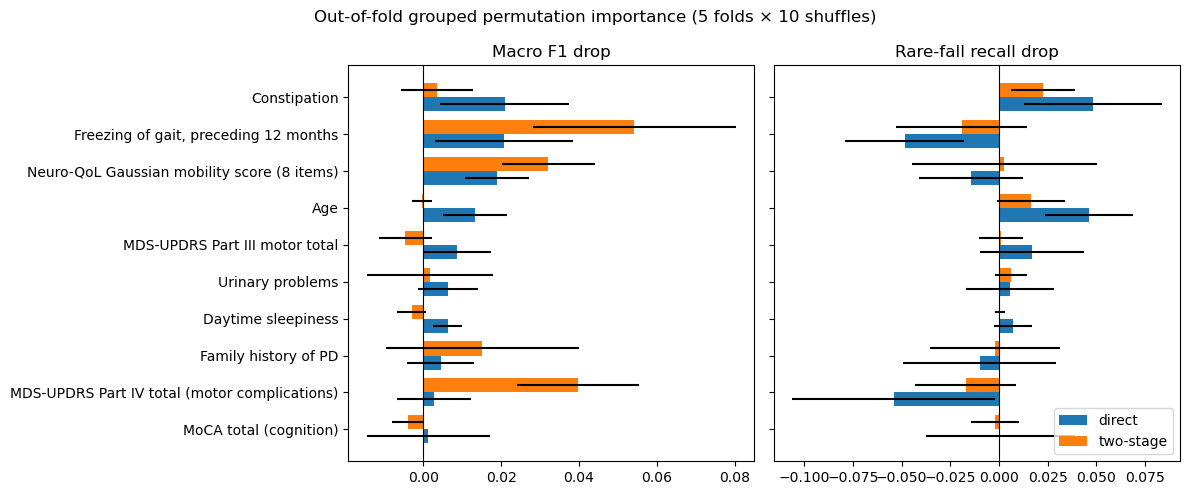

In [9]:
top_groups = (
    importance_summary.query("model == 'direct_system' and metric == 'macro_f1'")
    .nlargest(10, "mean_drop")["group"].tolist()[::-1]
)
figure, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for axis, metric, title in zip(axes, ["macro_f1", "rare_fall_recall"], ["Macro F1 drop", "Rare-fall recall drop"]):
    for offset, (model, color) in enumerate([("direct_system", "tab:blue"), ("two_stage_system", "tab:orange")]):
        rows = importance_summary.query("model == @model and metric == @metric").set_index("group").loc[top_groups]
        positions = np.arange(len(top_groups)) + (offset - 0.5) * 0.38
        axis.barh(positions, rows["mean_drop"], height=0.38, xerr=rows["sd_drop"], color=color,
                  label=model.replace("_system", "").replace("_", "-"))
    axis.axvline(0, color="black", linewidth=0.8)
    axis.set_title(title)
axes[0].set_yticks(np.arange(len(top_groups)), [LABELS[group] for group in top_groups])
axes[1].legend(loc="lower right")
figure.suptitle("Out-of-fold grouped permutation importance (5 folds × 10 shuffles)")
figure.tight_layout()
figure_path = output_directory / "system_permutation_importance.png"
figure_buffer = io.BytesIO()
figure.savefig(figure_buffer, format="png", dpi=200, bbox_inches="tight")
figure_bytes = figure_buffer.getvalue()
if figure_path.is_file():
    if figure_path.read_bytes() != figure_bytes:
        raise FileExistsError(
            "Existing figure differs and was not overwritten: "
            f"{figure_path.name}"
        )
    figure_status = "already identical"
else:
    figure_path.write_bytes(figure_bytes)
    figure_status = "created"
plt.show()

## 10. Validate and save

Confirm complete coverage and bounded results, then save the tables. Existing differing files are never overwritten.

In [10]:
validation = pd.DataFrame([
    {"check": "model files match Notebook 09 hashes", "passed": all(
        file_digest(full_fit_directory / "models" / entry["file"]) == entry["sha256"]
        for entry in model_manifest["models"].values()
    )},
    {"check": "every source variable is in exactly one group", "passed": sorted(covered) == sorted(predictors.columns)},
    {"check": "every fold, group, and score evaluated", "passed": len(fold_importance) == 5 * len(permutation_groups) * 7},
    {"check": "drops are finite and within [-1, 1]", "passed": bool(fold_importance["mean_drop"].between(-1, 1).all())},
    {"check": "retention covers 3 targets x all groups", "passed": len(retention) == 3 * len(permutation_groups)},
    {"check": "outer refits cover 20 seeds per target", "passed": bool(retention["outer_refits"].eq(20).all())},
])
display(validation)
assert validation["passed"].all()


def save_new_or_equivalent(frame, file_path):
    if file_path.is_file():
        existing = pd.read_csv(file_path)
        current = pd.read_csv(io.StringIO(frame.to_csv(index=False)))
        pd.testing.assert_frame_equal(current, existing, check_exact=False, rtol=1e-10)
        return "already equivalent"
    frame.to_csv(file_path, index=False)
    return "created"


artifacts = {
    "feature_summary.csv": feature_summary,
    "permutation_importance_summary.csv": importance_summary,
    "permutation_importance_by_fold.csv": fold_importance,
    "reference_out_of_fold_scores.csv": baseline_summary,
    "interpretation_validation.csv": validation,
}
display(pd.DataFrame([
    {"artifact": name, "status": save_new_or_equivalent(frame, output_directory / name), "rows": len(frame)}
    for name, frame in artifacts.items()
]))
print("Figure:", figure_path.relative_to(project_root), f"({figure_status})")

,check,passed
0,model files match Notebook 09 hashes,True
1,every source variable is in exactly one group,True
2,"every fold, group, and score evaluated",True
3,"drops are finite and within [-1, 1]",True
4,retention covers 3 targets x all groups,True
5,outer refits cover 20 seeds per target,True


,artifact,status,rows
0,feature_summary.csv,created,78
1,permutation_importance_summary.csv,created,182
2,permutation_importance_by_fold.csv,created,910
3,reference_out_of_fold_scores.csv,created,7
4,interpretation_validation.csv,created,6


Figure: results/final_pipeline/08_interpretation_and_reporting/10_model_interpretation/system_permutation_importance.png (created)


## Interpretation boundary

These summaries explain the locked final models without changing them. Report them alongside Notebook 07's outer performance, not as evidence that a variable causes falls. Correlated variables, such as the Part III total, gait, and postural stability, can share importance, so a low drop does not mean a variable is uninformative.